In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# pandas 3.0 uses new Arrow string type by default which crashes with numpy 2.4
# this setting reverts to old object dtype which is compatible
pd.options.future.infer_string = False

df = pd.read_csv('../data/raw/buyers.csv')
print("Shape:", df.shape)
df.head()

Shape: (4080, 8)


,buyer_id,first_name,last_name,email,phone,buyer_type,pre_approval_amount,registration_date
0,BYR-0001,Willie,Thompson,pughdavid@example.net,656-228-1827x6243,Individual,439789.50,2023-07-01
1,BYR-0002,Joshua,Hawkins,kevincollins@example.com,001-711-327-8956x7538,Investor,1816145.77,2019-05-31
2,BYR-0003,Nicole,Cross,zacharyhansen@example.org,(700)234-7464x92903,Individual,1282358.75,2024-03-06
3,BYR-0004,Michael,Riley,michellewagner@example.net,001-203-521-6215x975,Investor,831589.96,2021-06-16
4,BYR-0005,Jennifer,Johnson,hector91@example.org,+1-799-827-4871x048,Individual,1826786.62,2021-06-11


In [21]:
df.shape

(4080, 8)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   buyer_id             4080 non-null   object 
 1   first_name           4080 non-null   object 
 2   last_name            4080 non-null   object 
 3   email                3872 non-null   object 
 4   phone                4080 non-null   object 
 5   buyer_type           4080 non-null   object 
 6   pre_approval_amount  3474 non-null   float64
 7   registration_date    4080 non-null   object 
dtypes: float64(1), object(7)
memory usage: 255.1+ KB


In [23]:
df.isnull().sum()

buyer_id                 0
first_name               0
last_name                0
email                  208
phone                    0
buyer_type               0
pre_approval_amount    606
registration_date        0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(80)

In [25]:
# Step 1: Remove Duplicate Rows

# check how many duplicates exist before cleaning
print("Duplicates found:", df.duplicated().sum())
print("Before:", df.shape[0], "rows")

# drop duplicate rows, keep first occurrence
df = df.drop_duplicates().reset_index(drop=True)

print("After: ", df.shape[0], "rows")

Duplicates found: 80
Before: 4080 rows
After:  4000 rows


In [26]:
# Step 2: Standardize buyer_type Column
# problem: column may have inconsistent casing or whitespace
# solution: strip whitespace and apply title case

print("Before - unique values:", df['buyer_type'].unique())

df['buyer_type'] = df['buyer_type'].str.strip().str.title()

print("After  - unique values:", df['buyer_type'].unique())

Before - unique values: ['Individual' 'Investor' 'Trust' 'Corporation']
After  - unique values: ['Individual' 'Investor' 'Trust' 'Corporation']


In [27]:
# Step 3: Convert registration_date to DateTime
# problem: registration_date is stored as string (object), should be datetime for date operations

print("Before dtype:", df['registration_date'].dtype)
print("Sample:", df['registration_date'].head(3).tolist())

# convert string to datetime — format is already consistent (YYYY-MM-DD)
df['registration_date'] = pd.to_datetime(df['registration_date'])

print("After dtype: ", df['registration_date'].dtype)
print("Sample:", df['registration_date'].head(3).tolist())

Before dtype: object
Sample: ['2023-07-01', '2019-05-31', '2024-03-06']
After dtype:  datetime64[ns]
Sample: [Timestamp('2023-07-01 00:00:00'), Timestamp('2019-05-31 00:00:00'), Timestamp('2024-03-06 00:00:00')]


In [28]:
# Step 4: Standardize Phone Numbers
# problem: multiple formats exist — (xxx)xxx-xxxx, xxx.xxx.xxxx, digits only, with extensions
# solution: remove all non-digit characters only (brackets, dots, dashes, spaces)

print("Before - sample values:", df['phone'].head(5).tolist())

# remove all non-digit characters — do NOT trim to 10 digits
# because dataset has numbers ranging from 10 to 18 digits
df['phone'] = df['phone'].apply(lambda x: re.sub(r'\D', '', str(x)))

print("After  - sample values:", df['phone'].head(5).tolist())
print("\nDigit count distribution:")
print(df['phone'].str.len().value_counts().sort_index())

Before - sample values: ['656-228-1827x6243', '001-711-327-8956x7538', '(700)234-7464x92903', '001-203-521-6215x975', '+1-799-827-4871x048']
After  - sample values: ['65622818276243', '00171132789567538', '700234746492903', '0012035216215975', '17998274871048']

Digit count distribution:
phone
10    1313
11     164
13     638
14     659
15     641
16     279
17     153
18     153
Name: count, dtype: int64


In [29]:
# Step 5: Handle Invalid Emails
# problem: some emails may not contain '@' — these are invalid
# solution: fill invalid emails with "invalid email" instead of dropping rows

# find all rows where email does not contain '@'
invalid_mask = ~df['email'].str.contains('@', na=False)
print("Invalid emails found:", invalid_mask.sum())
print("Before:", df.loc[invalid_mask, 'email'].tolist())

# replace invalid emails with "invalid email" — row is preserved, only email is marked
df.loc[invalid_mask, 'email'] = 'invalid email'

print("After:", df.loc[invalid_mask, 'email'].tolist())
print("Total rows preserved:", df.shape[0])

Invalid emails found: 204
Before: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 

In [30]:
# Step 6: Validate pre_approval_amount
# expected range: positive values only (amount cannot be zero or negative)

print("Min :", df['pre_approval_amount'].min())
print("Max :", df['pre_approval_amount'].max())
print("Mean:", round(df['pre_approval_amount'].mean(), 2))
print("Null values:", df['pre_approval_amount'].isna().sum())

# check if any values fall outside the expected range
invalid_amounts = df[df['pre_approval_amount'] <= 0]
print("Invalid amounts (zero or negative):", len(invalid_amounts))

if len(invalid_amounts) == 0:
    print("All pre_approval_amount values are valid (greater than 0)")

Min : 100034.58
Max : 2998840.28
Mean: 1544692.44
Null values: 598
Invalid amounts (zero or negative): 0
All pre_approval_amount values are valid (greater than 0)


In [31]:
# Outlier Detection: pre_approval_amount (IQR Method)

Q1 = df['pre_approval_amount'].quantile(0.25)
Q3 = df['pre_approval_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['pre_approval_amount'] < lower_bound) | (df['pre_approval_amount'] > upper_bound)]

print(f"Q1:          {Q1:,.2f}")
print(f"Q3:          {Q3:,.2f}")
print(f"IQR:         {IQR:,.2f}")
print(f"Lower Bound: {lower_bound:,.2f}")
print(f"Upper Bound: {upper_bound:,.2f}")
print(f"\nTotal outliers found: {len(outliers)}")
print(f"Outlier %: {round(len(outliers)/df['pre_approval_amount'].notna().sum()*100, 2)}%")

if len(outliers) > 0:
    print("\nOutlier breakdown by buyer_type:")
    print(outliers['buyer_type'].value_counts())

Q1:          836,926.96
Q3:          2,255,631.45
IQR:         1,418,704.48
Lower Bound: -1,291,129.76
Upper Bound: 4,383,688.17

Total outliers found: 0
Outlier %: 0.0%


C:\Users\dell\AppData\Local\Temp\ipykernel_12712\4166875877.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_type, labels=buyer_types, patch_artist=True)


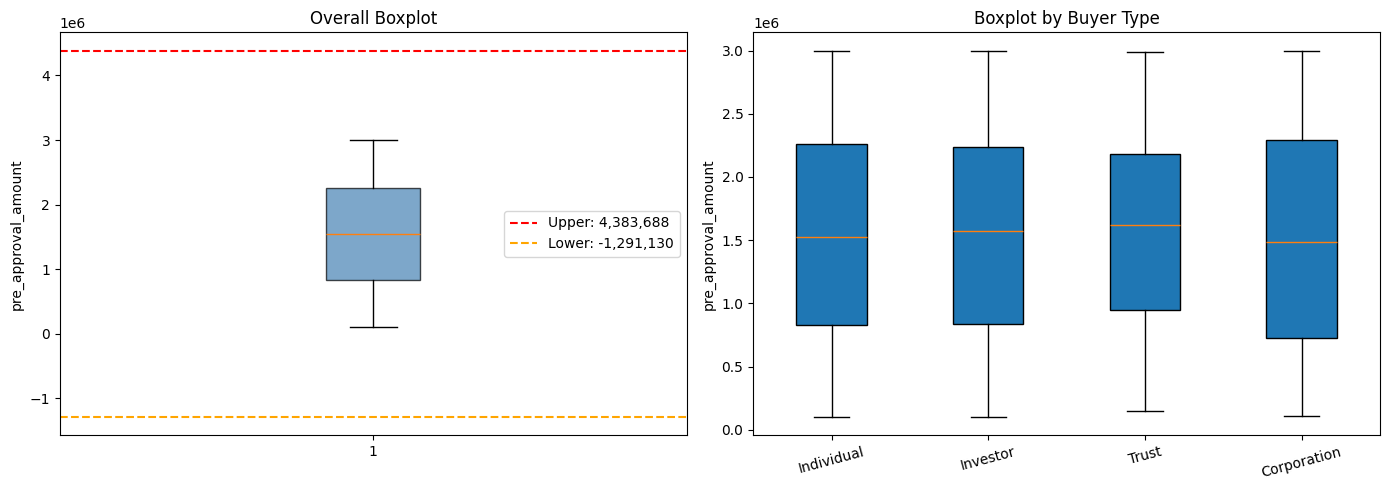

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot overall
axes[0].boxplot(df['pre_approval_amount'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].axhline(upper_bound, color='red', linestyle='--', label=f'Upper: {upper_bound:,.0f}')
axes[0].axhline(lower_bound, color='orange', linestyle='--', label=f'Lower: {lower_bound:,.0f}')
axes[0].set_title('Overall Boxplot')
axes[0].set_ylabel('pre_approval_amount')
axes[0].legend()

# Boxplot by buyer_type
buyer_types = df['buyer_type'].unique()
data_by_type = [df[df['buyer_type'] == bt]['pre_approval_amount'].dropna() for bt in buyer_types]
axes[1].boxplot(data_by_type, labels=buyer_types, patch_artist=True)
axes[1].set_title('Boxplot by Buyer Type')
axes[1].set_ylabel('pre_approval_amount')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [33]:
# Step 6 (updated): Fill Null pre_approval_amount with Group Median by buyer_type

print("Nulls before:", df['pre_approval_amount'].isna().sum())

print("\nMedian by buyer_type:")
print(df.groupby('buyer_type')['pre_approval_amount'].median().round(2))

df['pre_approval_amount'] = df.groupby('buyer_type')['pre_approval_amount'] \
    .transform(lambda x: x.fillna(x.median()))

print("\nNulls after:", df['pre_approval_amount'].isna().sum())
print("All nulls filled successfully!")

Nulls before: 598

Median by buyer_type:
buyer_type
Corporation    1484279.23
Individual     1526536.06
Investor       1573199.77
Trust          1621959.38
Name: pre_approval_amount, dtype: float64

Nulls after: 0
All nulls filled successfully!


In [36]:
# Save Cleaned Data

df.to_csv('../data/cleaned/clean-buyers.csv', index=False)

print("Cleaned file saved to: data/cleaned/clean-buyers.csv")
print("Final shape:", df.shape)
print("\nFinal dtypes:")
print(df.dtypes)

Cleaned file saved to: data/cleaned/clean-buyers.csv
Final shape: (4000, 8)

Final dtypes:
buyer_id                       object
first_name                     object
last_name                      object
email                          object
phone                          object
buyer_type                     object
pre_approval_amount           float64
registration_date      datetime64[ns]
dtype: object
